In [17]:
# ============================================================
# CELL 1 — CHECK GPU
# ============================================================
import torch
print('GPU available:', torch.cuda.is_available())
print('GPU name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU — go to Runtime > Change runtime type > T4 GPU')

# RUN THIS EVERY TIME KAGGLE RESETS
import os

# Re-download and extract
!pip install gdown --quiet
!gdown "1o0JGyAuVkdbSohdXR88HwqHT5ILU0xHz" -O /kaggle/working/nuscenes-mini.tgz

os.makedirs('/kaggle/working/nuscenes', exist_ok=True)
!tar -xzf /kaggle/working/nuscenes-mini.tgz -C /kaggle/working/nuscenes/

print("Done! Contents:", os.listdir('/kaggle/working/nuscenes'))

GPU available: True
GPU name: Tesla T4
Downloading...
From (original): https://drive.google.com/uc?id=1o0JGyAuVkdbSohdXR88HwqHT5ILU0xHz
From (redirected): https://drive.google.com/uc?id=1o0JGyAuVkdbSohdXR88HwqHT5ILU0xHz&confirm=t&uuid=849349b6-2175-4f49-9995-c7616b3a110c
To: /kaggle/working/nuscenes-mini.tgz
100%|██████████████████████████████████████| 4.17G/4.17G [00:43<00:00, 96.2MB/s]
Done! Contents: ['.v1.0-mini.txt', 'maps', 'LICENSE', 'v1.0-mini', 'samples', 'sweeps']


In [20]:
# ============================================================
# CELL 2 — MOUNT DRIVE AND EXTRACT DATASET
# ============================================================

# Extract dataset — takes 5-10 minutes
import os
print(os.listdir('/kaggle/working/nuscenes'))
print("Data ready!")

['.v1.0-mini.txt', 'maps', 'LICENSE', 'v1.0-mini', 'samples', 'sweeps']
Data ready!


In [21]:
# ============================================================
# CELL 3 — LOAD DATA USING JSON (no nuscenes library needed)
# ============================================================
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

dataroot = '/kaggle/working/nuscenes'

# Load JSON files directly
with open(f'{dataroot}/v1.0-mini/sample.json') as f:
    samples = json.load(f)

with open(f'{dataroot}/v1.0-mini/sample_data.json') as f:
    sample_datas = json.load(f)

with open(f'{dataroot}/v1.0-mini/sample_annotation.json') as f:
    annotations = json.load(f)

with open(f'{dataroot}/v1.0-mini/category.json') as f:
    categories = json.load(f)

with open(f'{dataroot}/v1.0-mini/instance.json') as f:
    instances = json.load(f)

# Build lookup dictionaries
sample_data_by_token = {sd['token']: sd for sd in sample_datas}
category_by_token    = {cat['token']: cat for cat in categories}
instance_by_token    = {inst['token']: inst for inst in instances}
annotation_by_token  = {ann['token']: ann for ann in annotations}

print(f'Samples loaded:     {len(samples)}')
print(f'Sample datas:       {len(sample_datas)}')
print(f'Annotations:        {len(annotations)}')
print(f'Categories:         {len(categories)}')
print('\nAll categories:')
for cat in categories:
    print(' -', cat['name'])

Samples loaded:     404
Sample datas:       31206
Annotations:        18538
Categories:         23

All categories:
 - human.pedestrian.adult
 - human.pedestrian.child
 - human.pedestrian.wheelchair
 - human.pedestrian.stroller
 - human.pedestrian.personal_mobility
 - human.pedestrian.police_officer
 - human.pedestrian.construction_worker
 - animal
 - vehicle.car
 - vehicle.motorcycle
 - vehicle.bicycle
 - vehicle.bus.bendy
 - vehicle.bus.rigid
 - vehicle.truck
 - vehicle.construction
 - vehicle.emergency.ambulance
 - vehicle.emergency.police
 - vehicle.trailer
 - movable_object.barrier
 - movable_object.trafficcone
 - movable_object.pushable_pullable
 - movable_object.debris
 - static_object.bicycle_rack


Image path: /kaggle/working/nuscenes/samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg


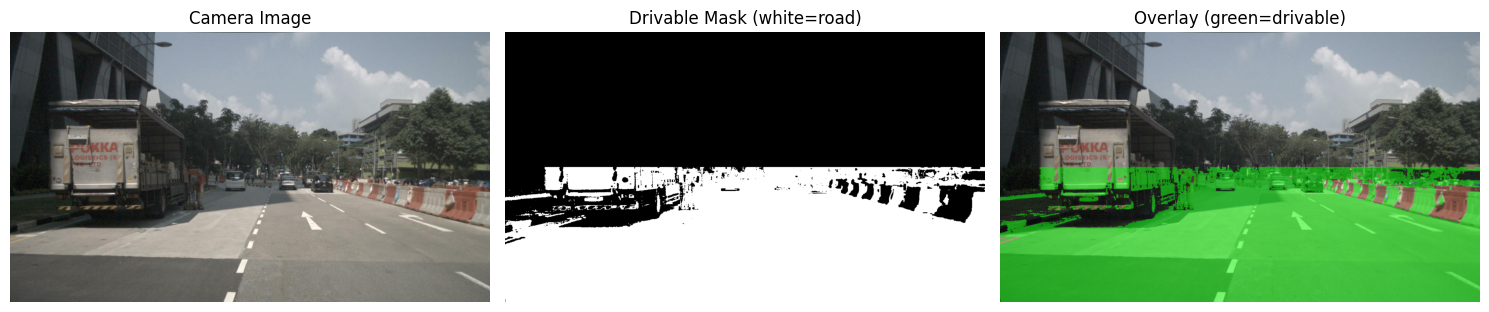

Image shape: (900, 1600, 3)
Mask shape:  (900, 1600)
Road pixels: 617197 / 1440000 (42.9%)


In [28]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def get_front_cam_path(sample):
    for sd in sample_datas:
        if sd['sample_token'] == sample['token'] and 'CAM_FRONT' in sd['filename'] and 'CAM_FRONT_LEFT' not in sd['filename'] and 'CAM_FRONT_RIGHT' not in sd['filename']:
            return os.path.join(dataroot, sd['filename'])
    return None

def create_road_mask(img_array):
    h, w = img_array.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    r, g, b = img_array[:,:,0], img_array[:,:,1], img_array[:,:,2]
    gray = np.mean(img_array, axis=2)

    color_diff = (np.abs(r.astype(int) - g.astype(int)) +
                  np.abs(g.astype(int) - b.astype(int)) +
                  np.abs(r.astype(int) - b.astype(int)))

    is_gray          = color_diff < 60
    is_bright_enough = gray > 40
    is_lower_half    = np.zeros((h, w), dtype=bool)
    is_lower_half[h//2:, :] = True

    mask[(is_gray & is_bright_enough & is_lower_half)] = 1
    return mask

# Test on first sample
sample   = samples[0]
img_path = get_front_cam_path(sample)
print('Image path:', img_path)

img  = np.array(Image.open(img_path).convert('RGB'))
mask = create_road_mask(img)

# Visualize
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title('Camera Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('Drivable Mask (white=road)')
plt.axis('off')

plt.subplot(1, 3, 3)
overlay = img.copy().astype(float)
overlay[mask == 1] = overlay[mask == 1] * 0.5 + np.array([0, 255, 0]) * 0.5
plt.imshow(overlay.astype(np.uint8))
plt.title('Overlay (green=drivable)')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f'Image shape: {img.shape}')
print(f'Mask shape:  {mask.shape}')
print(f'Road pixels: {mask.sum()} / {mask.size} ({100*mask.mean():.1f}%)')

In [ ]:
# ============================================================
# CELL 5 — BUILD FULL DATASET (all 404 samples)
# ============================================================
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random

IMG_SIZE = 256  # resize all images to 256x256

class DrivableDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.augment = augment
        self.data = []

        print('Building dataset...')
        for sample in samples:
            img_path = get_front_cam_path(sample)
            if img_path and os.path.exists(img_path):
                self.data.append(img_path)

        print(f'Dataset ready: {len(self.data)} images')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Load image
        img = np.array(Image.open(self.data[idx]).convert('RGB'))

        # Create mask
        mask = create_road_mask(img)

        # Resize to 256x256
        img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        # Augmentation (only during training)
        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                img  = np.fliplr(img).copy()
                mask = np.fliplr(mask).copy()
            # Random brightness
            if random.random() > 0.5:
                factor = random.uniform(0.7, 1.3)
                img = np.clip(img * factor, 0, 255).astype(np.uint8)

        # Convert to tensors
        img_tensor  = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return img_tensor, mask_tensor


# Split into train (80%) and val (20%)
split = int(0.8 * len(samples))
train_samples = samples[:split]
val_samples   = samples[split:]

train_dataset = DrivableDataset(train_samples, augment=True)
val_dataset   = DrivableDataset(val_samples,   augment=False)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

# Quick sanity check
imgs, masks = next(iter(train_loader))
print(f'Batch image shape: {imgs.shape}')   # [8, 3, 256, 256]
print(f'Batch mask shape:  {masks.shape}')  # [8, 1, 256, 256]

In [9]:
# ============================================================
# CELL 6 — U-NET MODEL (from scratch, no pretrained weights)
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """Two conv layers: Conv -> BN -> ReLU -> Conv -> BN -> ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        # Encoder (shrink)
        self.enc1 = DoubleConv(3,   64)
        self.enc2 = DoubleConv(64,  128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder (grow)
        self.up4  = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3  = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # Output: 1 channel binary mask
        self.output = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder with skip connections
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.output(d1)


# Test model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = UNet().to(device)

test_in  = torch.randn(2, 3, 256, 256).to(device)
test_out = model(test_in)
print(f'Input shape:  {test_in.shape}')
print(f'Output shape: {test_out.shape}')  # should be [2, 1, 256, 256]

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Input shape:  torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])
Total parameters: 31,037,633


In [10]:
# ============================================================
# CELL 7 — LOSS FUNCTION + OPTIMIZER
# ============================================================

def dice_loss(pred, target, smooth=1):
    """
    Dice loss handles class imbalance well.
    Road pixels are fewer than non-road, so BCE alone is not enough.
    """
    pred   = torch.sigmoid(pred)
    pred   = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return 1 - dice


def combined_loss(pred, target):
    """Dice loss + Binary Cross Entropy for best results"""
    bce  = F.binary_cross_entropy_with_logits(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print('Loss function and optimizer ready!')

Loss function and optimizer ready!


In [11]:
# ============================================================
# CELL 8 — MIOU METRIC
# ============================================================

def calculate_miou(pred, target, threshold=0.5):
    """
    mIoU = mean Intersection over Union
    This is the main accuracy metric for segmentation.
    Score of 1.0 = perfect, 0.0 = completely wrong
    """
    pred_bin = (torch.sigmoid(pred) > threshold).float()

    # IoU for class 1 (road)
    intersection = (pred_bin * target).sum()
    union        = (pred_bin + target).clamp(0, 1).sum()
    iou_road     = (intersection + 1e-6) / (union + 1e-6)

    # IoU for class 0 (not road)
    pred_bg   = 1 - pred_bin
    target_bg = 1 - target
    intersection_bg = (pred_bg * target_bg).sum()
    union_bg        = (pred_bg + target_bg).clamp(0, 1).sum()
    iou_bg          = (intersection_bg + 1e-6) / (union_bg + 1e-6)

    miou = (iou_road + iou_bg) / 2
    return miou.item()


print('mIoU function ready!')

mIoU function ready!


In [12]:
# ============================================================
# CELL 9 — TRAINING LOOP
# ============================================================
import time

EPOCHS     = 40
best_miou  = 0.0
train_losses = []
val_mious    = []

print(f'Training on: {device}')
print(f'Epochs: {EPOCHS}')
print('=' * 50)

for epoch in range(EPOCHS):
    # ---- TRAIN ----
    model.train()
    total_loss = 0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ---- VALIDATE ----
    model.eval()
    total_miou = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            total_miou += calculate_miou(preds, masks)

    avg_miou = total_miou / len(val_loader)
    val_mious.append(avg_miou)

    # Save best model
    if avg_miou > best_miou:
        best_miou = avg_miou
        torch.save(model.state_dict(), '/content/best_model.pth')

    scheduler.step()

    print(f'Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | mIoU: {avg_miou:.4f} | Best: {best_miou:.4f}')

print('\nTraining complete!')
print(f'Best mIoU: {best_miou:.4f}')

Training on: cuda
Epochs: 40


NameError: name 'train_loader' is not defined

In [ ]:
# ============================================================
# CELL 10 — PLOT TRAINING CURVES
# ============================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-o', markersize=3)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_mious, 'g-o', markersize=3)
plt.title('Validation mIoU')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# CELL 11 — MEASURE FPS (inference speed)
# ============================================================
import time

# Load best model
model.load_state_dict(torch.load('/content/best_model.pth'))
model.eval()

# Warmup GPU
dummy = torch.randn(1, 3, 256, 256).to(device)
for _ in range(10):
    _ = model(dummy)

# Measure FPS over 100 runs
NUM_RUNS = 100
torch.cuda.synchronize()
start = time.time()

with torch.no_grad():
    for _ in range(NUM_RUNS):
        _ = model(dummy)

torch.cuda.synchronize()
end = time.time()

fps = NUM_RUNS / (end - start)
ms_per_frame = (end - start) / NUM_RUNS * 1000

print(f'FPS:            {fps:.1f}')
print(f'ms per frame:   {ms_per_frame:.2f} ms')
print(f'Best mIoU:      {best_miou:.4f}')
print()
if fps >= 30:
    print('REAL-TIME capable (>= 30 FPS)')
else:
    print('Below real-time — consider reducing model size')

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_model.pth'

In [14]:
# ============================================================
# CELL 12 — VISUALIZE PREDICTIONS
# ============================================================
model.eval()

imgs, masks = next(iter(val_loader))
imgs  = imgs.to(device)

with torch.no_grad():
    preds = model(imgs)
    preds = torch.sigmoid(preds)

# Show 4 examples
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('Results: Image | Ground Truth | Prediction', fontsize=14)

for i in range(4):
    img_np  = imgs[i].cpu().permute(1,2,0).numpy()
    mask_np = masks[i].cpu().squeeze().numpy()
    pred_np = preds[i].cpu().squeeze().numpy()
    pred_bin = (pred_np > 0.5).astype(float)

    axes[i,0].imshow(img_np)
    axes[i,0].set_title('Image')
    axes[i,0].axis('off')

    axes[i,1].imshow(mask_np, cmap='gray')
    axes[i,1].set_title('Ground Truth')
    axes[i,1].axis('off')

    axes[i,2].imshow(pred_bin, cmap='gray')
    axes[i,2].set_title('Prediction')
    axes[i,2].axis('off')

plt.tight_layout()
plt.show()

NameError: name 'val_loader' is not defined

In [15]:
# ============================================================
# CELL 13 — SAVE MODEL TO GOOGLE DRIVE
# ============================================================
import shutil

# Save to Drive so it persists after Colab resets
shutil.copy('/content/best_model.pth', '/content/drive/MyDrive/best_model.pth')

print('Model saved to Google Drive!')
print(f'Final mIoU: {best_miou:.4f}')
print(f'Final FPS:  {fps:.1f}')

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_model.pth'